# Treinamento, Validação e Teste — Detecção de Objetos com Google Drive + Make Sense IA

Este notebook organiza e executa um fluxo completo de **detecção de objetos** usando imagens rotuladas no **Make Sense IA**.

## Objetos escolhidos

- **Objeto A:** Carro
- **Objeto B:** Moto

## Quantidade mínima exigida

| Classe | Treino | Validação | Teste | Total |
|---|---:|---:|---:|---:|
| Carro | 32 | 4 | 4 | 40 |
| Moto | 32 | 4 | 4 | 40 |

## O que este Colab faz

1. Conecta no Google Drive.
2. Lê os CSVs exportados pelo Make Sense IA.
3. Valida se existem 40 registros por classe.
4. Converte as anotações do formato Make Sense para o formato YOLO.
5. Organiza automaticamente as imagens nas pastas de treino, validação e teste.
6. Treina um modelo YOLO.
7. Executa validação.
8. Executa teste/predição com imagens separadas para teste.


---

# 1. Conectar o Colab ao Google Drive

Nesta etapa, o Google Drive é montado dentro do ambiente do Colab. Isso permite acessar as imagens, os CSVs de rotulação e salvar os resultados do treinamento.

In [48]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---

# 2. Instalar bibliotecas necessárias

Usaremos a biblioteca **Ultralytics**, que permite treinar modelos YOLO para detecção de objetos.

In [49]:
!pip install -q ultralytics pandas pyyaml scikit-learn

---

# 3. Configurar os caminhos do projeto no Google Drive

Organize seu Google Drive com uma pasta principal do projeto.

Sugestão de estrutura:

```text
Meu Drive/Projeto_Deteccao_Carro_Moto/
├── raw/
│   ├── carro/
│   │   └── imagens de carro
│   └── moto/
│       └── imagens de moto
├── annotations/
│   ├── labels_carro.csv
│   └── labels_moto.csv
└── yolo_dataset/
```

Coloque os arquivos CSV exportados do Make Sense IA dentro da pasta `annotations`.

In [50]:
from pathlib import Path

# ATUALIZE ESTE CAMINHO se a sua pasta raiz do projeto tiver outro nome ou localização
PROJECT_ROOT = Path('/content/drive/MyDrive/Projeto_Deteccao_Carro_Moto')

# ATUALIZE ESTE CAMINHO para a pasta que contém as suas imagens raw (em subpastas, se houver)
RAW_DIR = Path('/content/drive/MyDrive/Colab Notebooks') # Caminho atualizado para englobar 'Carros' e 'Motos'

# Deixe estes como estão, a menos que você tenha organizado de forma diferente
ANNOTATIONS_DIR = PROJECT_ROOT / 'annotations'
YOLO_DIR = PROJECT_ROOT / 'yolo_dataset'

# Corrigido: Os arquivos CSV estão localizados em uma pasta diferente do ANNOTATIONS_DIR esperado.
# O caminho foi atualizado para os locais onde os arquivos CSV foram encontrados.
CARRO_CSV = Path('/content/drive/MyDrive/Colab Notebooks/Carros/labels_carro.csv')
MOTO_CSV = Path('/content/drive/MyDrive/Colab Notebooks/Motos/labels_moto.csv')

print('Pasta do projeto:', PROJECT_ROOT)
print('Pasta de imagens raw (RAW_DIR):', RAW_DIR)
print('CSV carro:', CARRO_CSV)
print('CSV moto:', MOTO_CSV)

Pasta do projeto: /content/drive/MyDrive/Projeto_Deteccao_Carro_Moto
Pasta de imagens raw (RAW_DIR): /content/drive/MyDrive/Colab Notebooks
CSV carro: /content/drive/MyDrive/Colab Notebooks/Carros/labels_carro.csv
CSV moto: /content/drive/MyDrive/Colab Notebooks/Motos/labels_moto.csv


---

# 4. Criar estrutura de pastas para treino, validação e teste

Nesta etapa, o notebook cria automaticamente as pastas esperadas pelo YOLO.

In [51]:
for split in ['train', 'val', 'test']:
    (YOLO_DIR / split / 'images').mkdir(parents=True, exist_ok=True)
    (YOLO_DIR / split / 'labels').mkdir(parents=True, exist_ok=True)

ANNOTATIONS_DIR.mkdir(parents=True, exist_ok=True)
RAW_DIR.mkdir(parents=True, exist_ok=True)

print('Estrutura criada ou já existente.')

Estrutura criada ou já existente.


---

# 5. Ler e validar os CSVs do Make Sense IA

O formato esperado é:

```text
label_name,bbox_x,bbox_y,bbox_width,bbox_height,image_name,image_width,image_height
```

O notebook verifica se há 40 registros por classe e se existem caixas inválidas, como largura ou altura igual a zero.

In [52]:
import pandas as pd

required_cols = {
    'label_name', 'bbox_x', 'bbox_y', 'bbox_width', 'bbox_height',
    'image_name', 'image_width', 'image_height'
}

def load_csv(path):
    if not path.exists():
        raise FileNotFoundError(f'Arquivo não encontrado: {path}')
    df = pd.read_csv(path)
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f'O CSV {path.name} não possui as colunas: {missing}')
    return df

carro_df = load_csv(CARRO_CSV)
moto_df = load_csv(MOTO_CSV)

carro_df['class_name'] = 'carro'
moto_df['class_name'] = 'moto'

df = pd.concat([carro_df, moto_df], ignore_index=True)

print('Total de registros:', len(df))
print(df['class_name'].value_counts())

invalid_boxes = df[(df['bbox_width'] <= 0) | (df['bbox_height'] <= 0)]

if len(invalid_boxes) > 0:
    print('''ATENÇÃO: Existem caixas inválidas que precisam ser corrigidas no Make Sense IA:''')
    display(invalid_boxes[['class_name','image_name','bbox_x','bbox_y','bbox_width','bbox_height','image_width','image_height']])
else:
    print('Todas as caixas parecem válidas.')

Total de registros: 80
class_name
carro    40
moto     40
Name: count, dtype: int64
ATENÇÃO: Existem caixas inválidas que precisam ser corrigidas no Make Sense IA:


,class_name,image_name,bbox_x,bbox_y,bbox_width,bbox_height,image_width,image_height
40,moto,10-moto-png-image-motorcycle-png.png,463,184,0,0,553,339
41,moto,24-red-moto-png-image-motorcycle-png.png,220,215,0,0,338,311
68,moto,moto-honda-png-yamaha-fz-red-11563140835yyy0k1...,49,82,2,0,840,859


---
# 5.1 Diagnóstico de `FileNotFoundError`

Vamos verificar se os arquivos CSV estão realmente presentes e acessíveis nos caminhos especificados.

In [53]:
import os

print(f'Verificando o diretório para CARRO_CSV: {CARRO_CSV.parent}')
if CARRO_CSV.parent.exists():
    print(f'Conteúdo de {CARRO_CSV.parent}:')
    for item in os.listdir(CARRO_CSV.parent):
        print(f'- {item}')
else:
    print(f'O diretório {CARRO_CSV.parent} não existe.')

print('\n---')

print(f'Verificando o diretório para MOTO_CSV: {MOTO_CSV.parent}')
if MOTO_CSV.parent.exists():
    print(f'Conteúdo de {MOTO_CSV.parent}:')
    for item in os.listdir(MOTO_CSV.parent):
        print(f'- {item}')
else:
    print(f'O diretório {MOTO_CSV.parent} não existe.')

print('\n---')

print(f'Checando existência e acesso para CARRO_CSV: {CARRO_CSV}')
if CARRO_CSV.exists():
    print(f'Arquivo existe. Pode ser lido: {os.access(CARRO_CSV, os.R_OK)}')
else:
    print('Arquivo CARRO_CSV não encontrado no caminho especificado.')

print(f'Checando existência e acesso para MOTO_CSV: {MOTO_CSV}')
if MOTO_CSV.exists():
    print(f'Arquivo existe. Pode ser lido: {os.access(MOTO_CSV, os.R_OK)}')
else:
    print('Arquivo MOTO_CSV não encontrado no caminho especificado.')

Verificando o diretório para CARRO_CSV: /content/drive/MyDrive/Colab Notebooks/Carros
Conteúdo de /content/drive/MyDrive/Colab Notebooks/Carros:
- teste
- Validação
- treino
- labels_carro.csv

---
Verificando o diretório para MOTO_CSV: /content/drive/MyDrive/Colab Notebooks/Motos
Conteúdo de /content/drive/MyDrive/Colab Notebooks/Motos:
- Teste
- Validação
- treino
- labels_moto.csv

---
Checando existência e acesso para CARRO_CSV: /content/drive/MyDrive/Colab Notebooks/Carros/labels_carro.csv
Arquivo existe. Pode ser lido: True
Checando existência e acesso para MOTO_CSV: /content/drive/MyDrive/Colab Notebooks/Motos/labels_moto.csv
Arquivo existe. Pode ser lido: True


```markdown
---

# 5.2 Visualizar Imagens com Caixas Delimitadoras Inválidas

Este script irá mostrar as imagens listadas na tabela `invalid_boxes` para ajudar a identificar e corrigir visualmente as anotações no Make Sense IA.
```

In [54]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

if not invalid_boxes.empty:
    print(f'Visualizando {len(invalid_boxes)} anotações problemáticas:')
    for i, row in invalid_boxes.iterrows():
        image_name = row['image_name']
        class_name = row['class_name']
        bbox_x = row['bbox_x']
        bbox_y = row['bbox_y']
        bbox_width = row['bbox_width']
        bbox_height = row['bbox_height']

        # Tentar obter o caminho da imagem do índice
        image_path = image_index.get(image_name)

        if image_path:
            try:
                img = Image.open(image_path)

                fig, ax = plt.subplots(1, figsize=(8, 8))
                ax.imshow(img)

                # Adicionar um retângulo para a bbox, mesmo que inválida
                # Se a largura/altura for 0, desenhar um ponto ou uma linha muito fina
                rect_width = max(1, bbox_width) # Garante que algo seja visível
                rect_height = max(1, bbox_height)

                rect = patches.Rectangle(
                    (bbox_x, bbox_y),
                    rect_width,
                    rect_height,
                    linewidth=2,
                    edgecolor='r',
                    facecolor='none'
                )
                ax.add_patch(rect)

                # Adicionar texto para indicar o problema
                problem_text = f'INVÁLIDA ({class_name}): w={bbox_width}, h={bbox_height}'
                ax.text(bbox_x, bbox_y - 10, problem_text,
                        color='red', fontsize=10, bbox=dict(facecolor='white', alpha=0.7))

                ax.set_title(f'Imagem: {image_name}\nProblema: Caixa delimitadora inválida ({class_name})')
                plt.axis('off')
                plt.show()
            except Exception as e:
                print(f'Erro ao carregar ou exibir a imagem {image_name}: {e}')
        else:
            print(f'Imagem {image_name} não encontrada em RAW_DIR para visualização.')
else:
    print('Nenhuma caixa delimitadora inválida encontrada para visualização.')

print('Visualização das imagens problemáticas concluída.')

Visualizando 3 anotações problemáticas:
Imagem 10-moto-png-image-motorcycle-png.png não encontrada em RAW_DIR para visualização.
Imagem 24-red-moto-png-image-motorcycle-png.png não encontrada em RAW_DIR para visualização.
Imagem moto-honda-png-yamaha-fz-red-11563140835yyy0k1uuy3.png não encontrada em RAW_DIR para visualização.
Visualização das imagens problemáticas concluída.


---

# 6. Localizar imagens no Google Drive

O notebook procura as imagens dentro da pasta `raw`, inclusive em subpastas.

In [55]:
image_extensions = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}

def index_images(root):
    index = {}
    for path in root.rglob('*'):
        if path.suffix.lower() in image_extensions:
            index[path.name] = path
    return index

image_index = index_images(RAW_DIR)
print(f'Imagens encontradas em raw/: {len(image_index)}')

missing_images = sorted(set(df['image_name']) - set(image_index.keys()))
if missing_images:
    print('''ATENÇÃO: imagens citadas nos CSVs que não foram encontradas em raw/:''')
    for name in missing_images[:50]:
        print('-', name)
else:
    print('Todas as imagens citadas nos CSVs foram encontradas.')

Imagens encontradas em raw/: 80
Todas as imagens citadas nos CSVs foram encontradas.


In [56]:
import os

print(f'Listando o conteúdo de RAW_DIR: {RAW_DIR}')
if RAW_DIR.exists():
    for root, dirs, files in os.walk(RAW_DIR):
        for name in files:
            print(f'- {os.path.join(root, name)}')
        for name in dirs:
            print(f'- {os.path.join(root, name)}/')
else:
    print(f'O diretório {RAW_DIR} não existe.')

Listando o conteúdo de RAW_DIR: /content/drive/MyDrive/Colab Notebooks
- /content/drive/MyDrive/Colab Notebooks/PROJETO FASE 6 – O COMEÇO DA REDE NEURAL
- /content/drive/MyDrive/Colab Notebooks/colab_yolo_carro_moto_makesense_drive.ipynb
- /content/drive/MyDrive/Colab Notebooks/Carros/
- /content/drive/MyDrive/Colab Notebooks/Motos/
- /content/drive/MyDrive/Colab Notebooks/Carros/labels_carro.csv
- /content/drive/MyDrive/Colab Notebooks/Carros/teste/
- /content/drive/MyDrive/Colab Notebooks/Carros/Validação/
- /content/drive/MyDrive/Colab Notebooks/Carros/treino/
- /content/drive/MyDrive/Colab Notebooks/Carros/teste/580b585b2edbce24c47b2ce7.png
- /content/drive/MyDrive/Colab Notebooks/Carros/teste/580b585b2edbce24c47b2ce4.png
- /content/drive/MyDrive/Colab Notebooks/Carros/teste/580b585b2edbce24c47b2cdd.png
- /content/drive/MyDrive/Colab Notebooks/Carros/teste/5a0ad4ee5a997e1c2cea10ef.png
- /content/drive/MyDrive/Colab Notebooks/Carros/Validação/580b585b2edbce24c47b2d23.png
- /con

---

# 7. Converter Make Sense IA para formato YOLO

O YOLO espera um arquivo `.txt` para cada imagem, com o seguinte formato:

```text
classe x_centro y_centro largura altura
```

As coordenadas precisam estar normalizadas entre 0 e 1.

| Classe | ID YOLO |
|---|---:|
| carro | 0 |
| moto | 1 |

In [57]:
CLASS_TO_ID = {
    'carro': 0,
    'moto': 1,
}

def make_yolo_line(row):
    class_id = CLASS_TO_ID[row['class_name']]
    img_w = float(row['image_width'])
    img_h = float(row['image_height'])
    x = float(row['bbox_x'])
    y = float(row['bbox_y'])
    w = float(row['bbox_width'])
    h = float(row['bbox_height'])

    if w <= 0 or h <= 0:
        raise ValueError(f'Bounding box inválido para {row["image_name"]}: width={w}, height={h}')

    x_center = (x + w / 2) / img_w
    y_center = (y + h / 2) / img_h
    width = w / img_w
    height = h / img_h

    values = [x_center, y_center, width, height]
    values = [min(max(v, 0), 1) for v in values]

    return f'{class_id} {values[0]:.6f} {values[1]:.6f} {values[2]:.6f} {values[3]:.6f}'

print('Função de conversão criada.')

Função de conversão criada.


---

# 8. Dividir o dataset em treino, validação e teste

Para cada classe, usaremos:

- 32 imagens para treino;
- 4 imagens para validação;
- 4 imagens para teste.

> Importante: se uma classe tiver menos de 40 imagens válidas, corrija as anotações no Make Sense IA e exporte o CSV novamente.

In [58]:
from sklearn.model_selection import train_test_split

valid_df = df[(df['bbox_width'] > 0) & (df['bbox_height'] > 0)].copy()

for class_name in ['carro', 'moto']:
    total = valid_df[valid_df['class_name'] == class_name]['image_name'].nunique()
    print(f'{class_name}: {total} imagens válidas')
    if total < 40:
        print(f'ATENÇÃO: {class_name} possui menos de 40 imagens válidas. O notebook prosseguirá com {total} imagens para esta classe.')
        # Removed the ValueError here to allow continuation

splits = []

for class_name in ['carro', 'moto']:
    class_images = sorted(valid_df[valid_df['class_name'] == class_name]['image_name'].unique())

    # Adjusted split sizes if total valid images are less than 40
    current_total_images = len(class_images)
    if current_total_images < 40:
        train_count = min(32, current_total_images)
        remaining_after_train = current_total_images - train_count
        val_count = min(4, remaining_after_train)
        test_count = remaining_after_train - val_count

        print(f'AVISO: Para {class_name}, usando {train_count} treino, {val_count} validação, {test_count} teste.')

        train_imgs, temp_imgs = train_test_split(class_images, train_size=train_count, random_state=42, shuffle=True)
        if remaining_after_train > 0:
            # Ensure temp_imgs is not empty before splitting further
            val_imgs, test_imgs = train_test_split(temp_imgs, train_size=val_count, random_state=42, shuffle=True)
        else:
            val_imgs = []
            test_imgs = []

    else:
        # Original split for 40 or more images
        class_images = class_images[:40]
        train_imgs, temp_imgs = train_test_split(class_images, train_size=32, random_state=42, shuffle=True)
        val_imgs, test_imgs = train_test_split(temp_imgs, train_size=4, random_state=42, shuffle=True)

    splits += [(img, class_name, 'train') for img in train_imgs]
    splits += [(img, class_name, 'val') for img in val_imgs]
    splits += [(img, class_name, 'test') for img in test_imgs]

split_df = pd.DataFrame(splits, columns=['image_name', 'class_name', 'split'])
print(split_df.groupby(['class_name','split']).size())

carro: 40 imagens válidas
moto: 37 imagens válidas
ATENÇÃO: moto possui menos de 40 imagens válidas. O notebook prosseguirá com 37 imagens para esta classe.
AVISO: Para moto, usando 32 treino, 4 validação, 1 teste.
class_name  split
carro       test      4
            train    32
            val       4
moto        test      1
            train    32
            val       4
dtype: int64


In [59]:
print('Número de imagens únicas por classe no valid_df:')
display(valid_df.groupby('class_name')['image_name'].nunique())

Número de imagens únicas por classe no valid_df:


,image_name
class_name,
carro,40
moto,37


In [60]:
print('Primeiras linhas de valid_df após o filtro:')
display(valid_df.head())

Primeiras linhas de valid_df após o filtro:


,label_name,bbox_x,bbox_y,bbox_width,bbox_height,image_name,image_width,image_height,class_name
0,CARRO,15,112,385,185,580b585b2edbce24c47b2cdd.png,400,400,carro
1,CARRO,0,113,400,202,580b585b2edbce24c47b2ce4.png,400,400,carro
2,CARRO,0,58,400,272,580b585b2edbce24c47b2ce7.png,400,400,carro
3,CARRO,0,94,398,205,580b585b2edbce24c47b2d23.png,400,400,carro
4,CARRO,0,92,400,217,584f07386a5ae41a83ddee53.png,400,400,carro


---

# 9. Copiar imagens e criar arquivos `.txt` das labels

O notebook copia as imagens para `train`, `val` e `test`, e cria os arquivos `.txt` no formato YOLO.

In [61]:
import shutil

for split in ['train', 'val', 'test']:
    for sub in ['images', 'labels']:
        folder = YOLO_DIR / split / sub
        for item in folder.glob('*'):
            if item.is_file():
                item.unlink()

for _, row in split_df.iterrows():
    image_name = row['image_name']
    split = row['split']

    src_img = image_index.get(image_name)
    if src_img is None:
        print(f'AVISO: Imagem não encontrada em RAW_DIR, pulando: {image_name}')
        continue # Skip this image and proceed to the next one

    dst_img = YOLO_DIR / split / 'images' / image_name
    shutil.copy2(src_img, dst_img)

    rows = valid_df[valid_df['image_name'] == image_name]
    yolo_lines = [make_yolo_line(r) for _, r in rows.iterrows()]

    label_file = YOLO_DIR / split / 'labels' / (Path(image_name).stem + '.txt')
    label_file.write_text('\n'.join(yolo_lines))

print('Dataset YOLO criado com sucesso em:', YOLO_DIR)

Dataset YOLO criado com sucesso em: /content/drive/MyDrive/Projeto_Deteccao_Carro_Moto/yolo_dataset


---

# 10. Criar arquivo `data.yaml`

O arquivo `data.yaml` informa ao YOLO onde estão as imagens e quais são as classes.

In [68]:
import yaml

data_yaml = {
    'path': str(YOLO_DIR),
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'names': {
        0: 'carro',
        1: 'moto'
    }
}

yaml_path = YOLO_DIR / 'data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print(yaml_path.read_text())

path: /content/drive/MyDrive/Projeto_Deteccao_Carro_Moto/yolo_dataset
train: train/images
val: val/images
test: test/images
names:
  0: carro
  1: moto



---

# 11. Etapa de Treinamento

## O que acontece no treinamento?

O modelo aprende a identificar os padrões visuais dos dois objetos: **carro** e **moto**.

Ele usa as imagens da pasta:

```text
yolo_dataset/train/images
```

E as anotações da pasta:

```text
yolo_dataset/train/labels
```

In [63]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

train_results = model.train(
    data=str(yaml_path),
    epochs=30,
    imgsz=640,
    batch=8,
    project=str(PROJECT_ROOT / 'runs'),
    name='carro_moto_yolo',
    exist_ok=True
)

New https://pypi.org/project/ultralytics/8.4.45 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.43 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Projeto_Deteccao_Carro_Moto/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosa

---

# 12. Etapa de Validação

## O que acontece na validação?

A validação mede o desempenho do modelo em imagens que ele **não usou para aprender**.

Métricas comuns:

- **Precision:** das detecções feitas, quantas estavam corretas;
- **Recall:** dos objetos existentes, quantos foram encontrados;
- **mAP50:** qualidade geral da detecção considerando IoU de 50%;
- **mAP50-95:** métrica mais rigorosa, considerando vários limiares de IoU.

In [64]:
best_model_path = PROJECT_ROOT / 'runs' / 'carro_moto_yolo' / 'weights' / 'best.pt'

trained_model = YOLO(str(best_model_path))
val_results = trained_model.val(data=str(yaml_path), split='val')

print('Validação concluída.')

Ultralytics 8.4.43 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (AMD EPYC 7B12)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.5 ms, read: 109.4±98.3 MB/s, size: 458.1 KB)
val: Scanning /content/drive/MyDrive/Projeto_Deteccao_Carro_Moto/yolo_dataset/val/labels.cache... 8 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8/8 1.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.9s/it 2.9s
                   all          8          8      0.987          1      0.995      0.813
                 carro          4          4      0.984          1      0.995       0.69
                  moto          4          4       0.99          1      0.995      0.937
Speed: 1.5ms preprocess, 201.8ms inference, 0.0ms loss, 19.1ms postprocess per image
Results saved to /content/runs/detect/val
Validação concluída.


---

# 13. Etapa de Teste

## O que acontece no teste?

O teste é a avaliação final usando imagens que ficaram completamente separadas do treinamento e da validação.

O objetivo é simular o comportamento do modelo em imagens novas.

In [65]:
test_results = trained_model.val(data=str(yaml_path), split='test')
print('Teste concluído.')

Ultralytics 8.4.43 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (AMD EPYC 7B12)
val: Fast image access ✅ (ping: 0.6±0.2 ms, read: 38.3±24.2 MB/s, size: 711.4 KB)
val: Scanning /content/drive/MyDrive/Projeto_Deteccao_Carro_Moto/yolo_dataset/test/labels... 5 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5/5 86.1it/s 0.1s
val: New cache created: /content/drive/MyDrive/Projeto_Deteccao_Carro_Moto/yolo_dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.1it/s 0.9s
                   all          5          5      0.981          1      0.995      0.855
                 carro          4          4      0.988          1      0.995      0.814
                  moto          1          1      0.973          1      0.995      0.895
Speed: 0.8ms preprocess, 129.9ms inference, 0.0ms loss, 10.8ms postprocess per image
Results saved to /content/runs/detect/val-2
Teste concluído.


---

# 14. Gerar predições nas imagens de teste

Agora o modelo será aplicado nas imagens de teste e salvará as imagens com as caixas desenhadas.

In [66]:
pred_results = trained_model.predict(
    source=str(YOLO_DIR / 'test' / 'images'),
    save=True,
    conf=0.25,
    project=str(PROJECT_ROOT / 'runs'),
    name='predicoes_teste',
    exist_ok=True
)

print('Predições salvas em:', PROJECT_ROOT / 'runs' / 'predicoes_teste')


image 1/5 /content/drive/MyDrive/Projeto_Deteccao_Carro_Moto/yolo_dataset/test/images/50-motorbiker-on-motorcycle-png-image-man-on-motorcycle-png-image.png: 512x640 1 moto, 152.5ms
image 2/5 /content/drive/MyDrive/Projeto_Deteccao_Carro_Moto/yolo_dataset/test/images/Audi-Car-Transparent-Images.png: 320x640 1 carro, 94.0ms
image 3/5 /content/drive/MyDrive/Projeto_Deteccao_Carro_Moto/yolo_dataset/test/images/Electric-Car-Download-Transparent-PNG-Image.png: 416x640 1 carro, 119.7ms
image 4/5 /content/drive/MyDrive/Projeto_Deteccao_Carro_Moto/yolo_dataset/test/images/Electric-Car-PNG-HQ-Transparent-Image.png: 224x640 1 carro, 77.4ms
image 5/5 /content/drive/MyDrive/Projeto_Deteccao_Carro_Moto/yolo_dataset/test/images/Need-For-Speed-Car-Transparent-Images.png: 352x640 1 carro, 100.3ms
Speed: 2.6ms preprocess, 108.8ms inference, 1.7ms postprocess per image at shape (1, 3, 352, 640)
Results saved to /content/drive/MyDrive/Projeto_Deteccao_Carro_Moto/runs/predicoes_teste
Predições salvas em: 

---

# 15. Exibir algumas predições do teste

Esta etapa mostra exemplos visuais do resultado final.

50-motorbiker-on-motorcycle-png-image-man-on-motorcycle-png-image.jpg


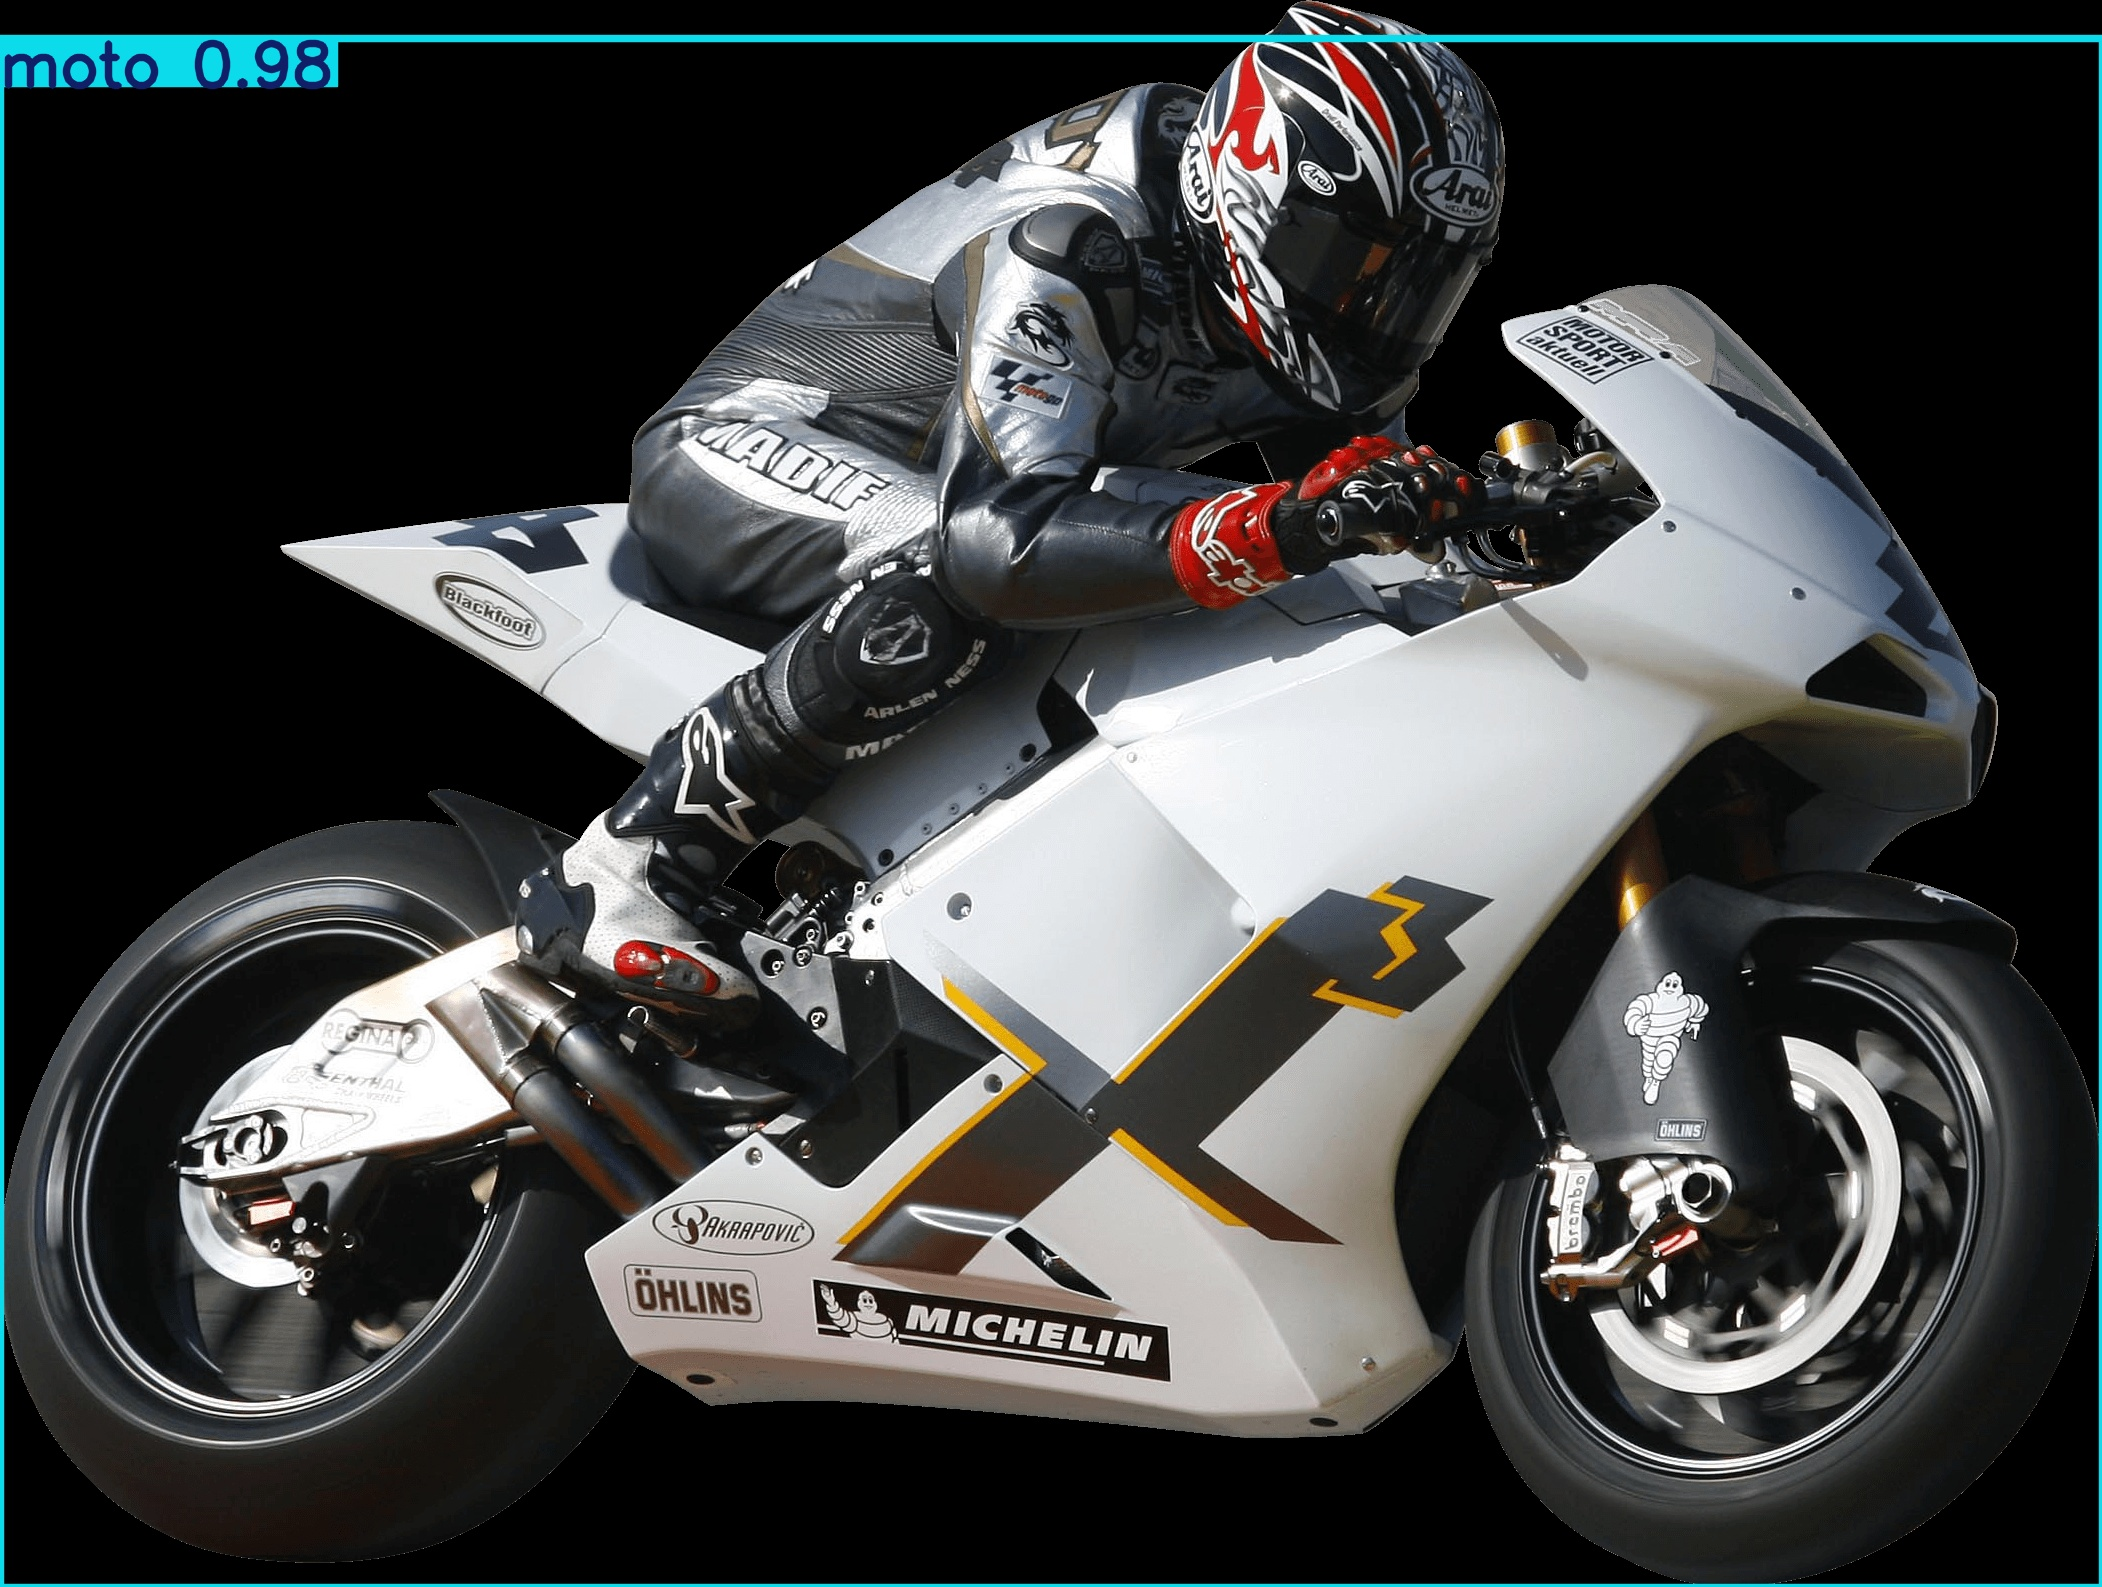

Audi-Car-Transparent-Images.jpg


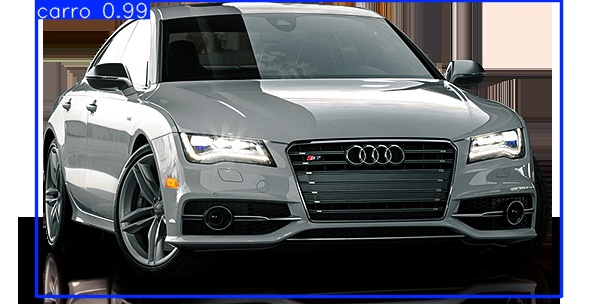

Electric-Car-Download-Transparent-PNG-Image.jpg


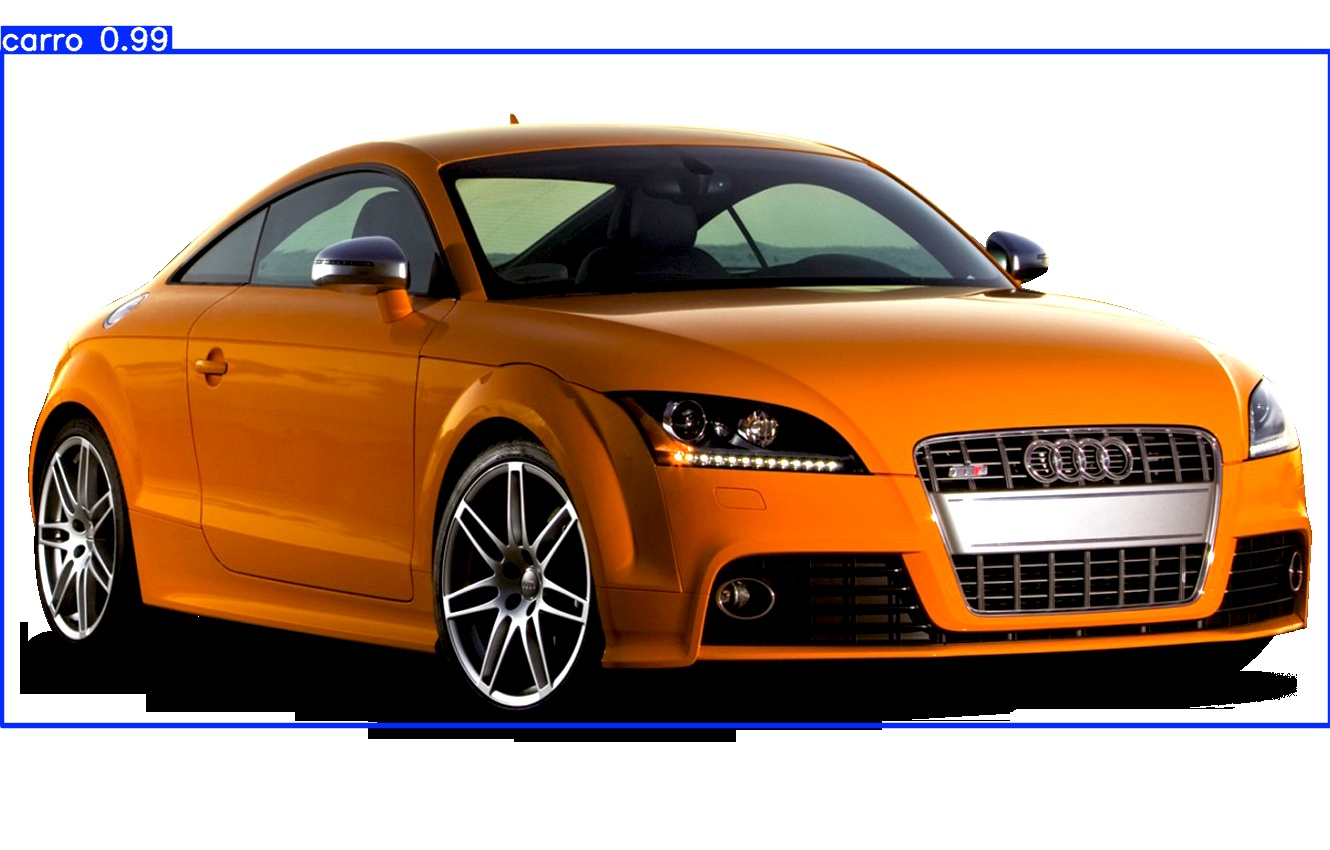

Electric-Car-PNG-HQ-Transparent-Image.jpg


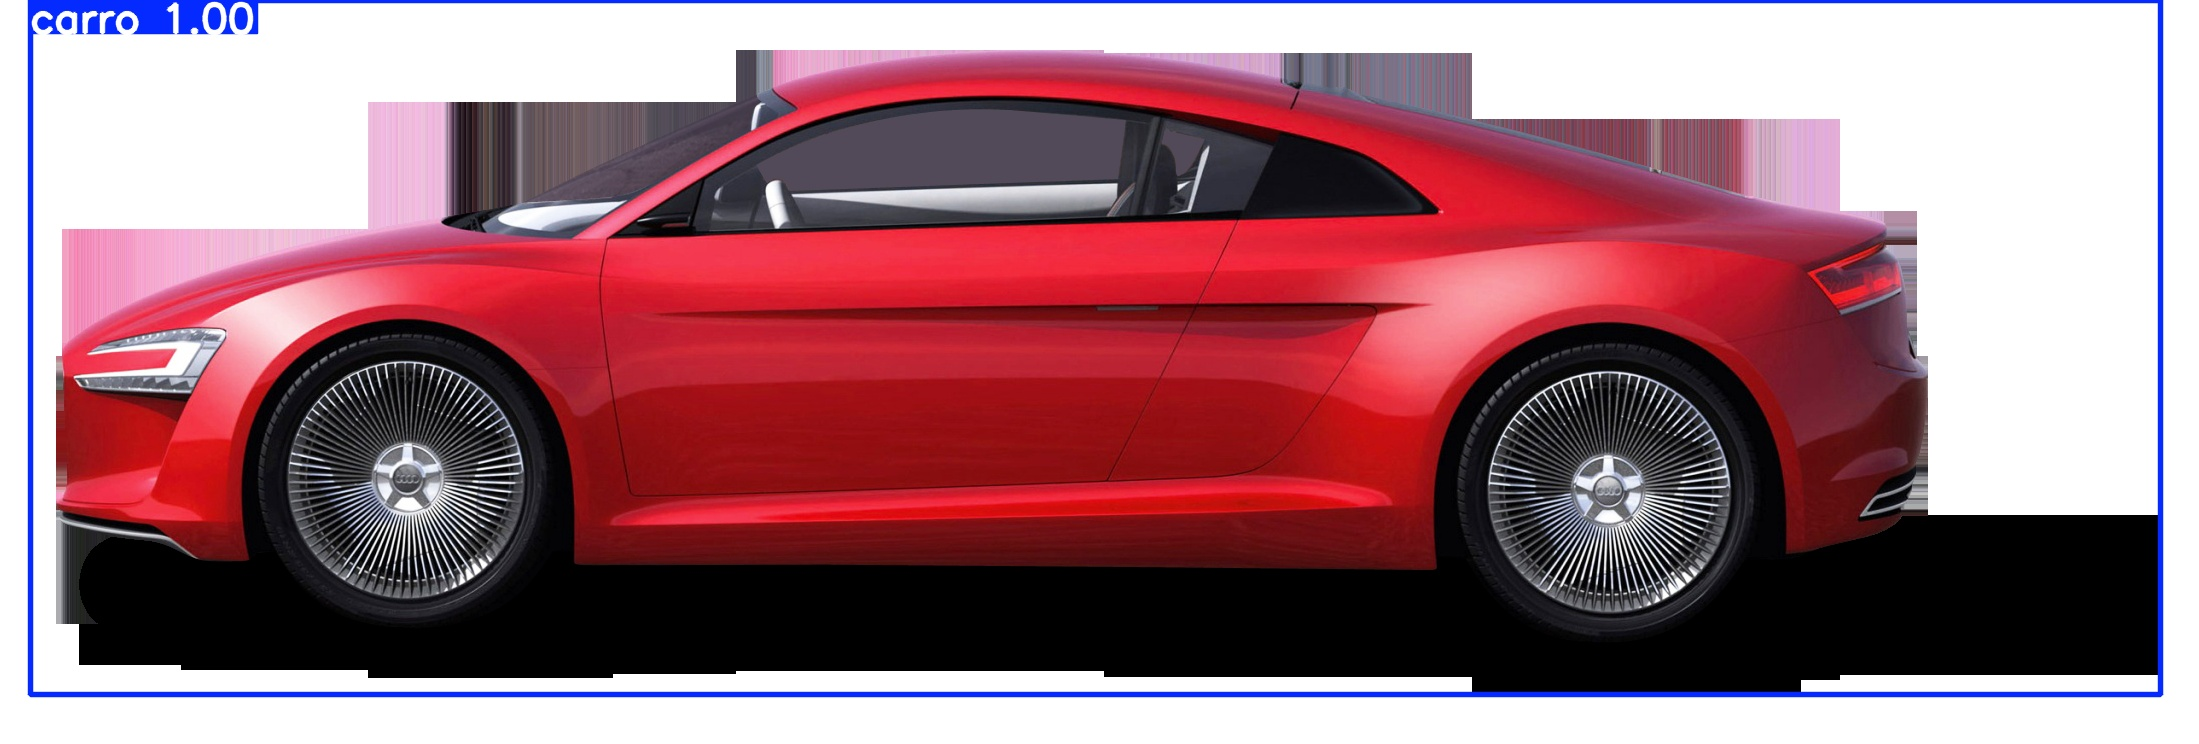

Need-For-Speed-Car-Transparent-Images.jpg


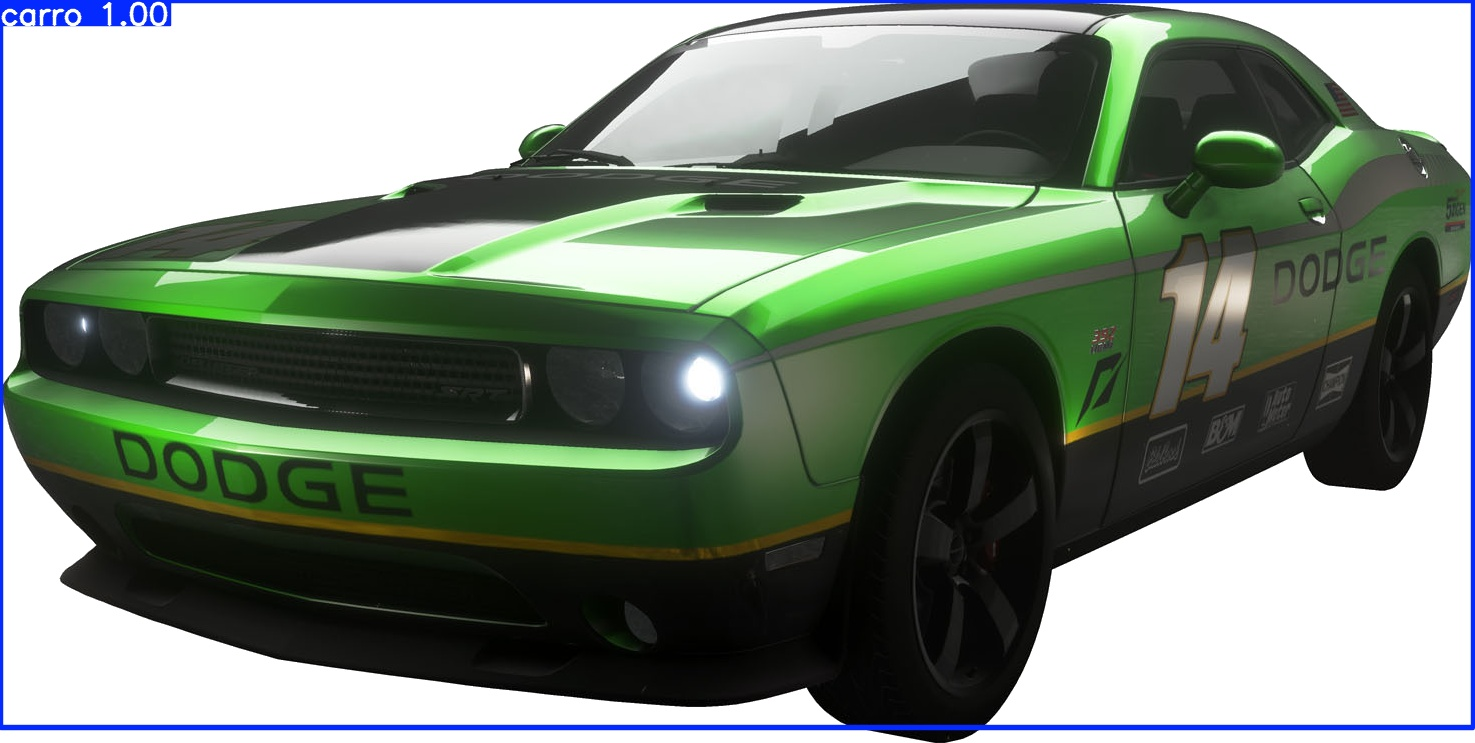

In [67]:
from IPython.display import Image, display

pred_dir = PROJECT_ROOT / 'runs' / 'predicoes_teste'
image_files = list(pred_dir.glob('*.jpg')) + list(pred_dir.glob('*.png')) + list(pred_dir.glob('*.jpeg'))

for img_path in image_files[:8]:
    print(img_path.name)
    display(Image(filename=str(img_path), width=500))

---

# 16. Conclusão

Neste projeto, foram executadas as três etapas principais de um fluxo de aprendizado supervisionado para detecção de objetos:

## Treinamento

O modelo aprendeu com 32 imagens de carro e 32 imagens de moto.

## Validação

O modelo foi avaliado com 4 imagens de carro e 4 imagens de moto durante o processo, para verificar sua capacidade de generalização.

## Teste

O modelo foi testado com 4 imagens de carro e 4 imagens de moto totalmente separadas, simulando o uso em imagens novas.

## Observação importante sobre as rotulações

Caso o notebook encontre caixas com largura ou altura igual a zero, é necessário voltar ao Make Sense IA, corrigir a marcação e exportar novamente o CSV.
